# BoTorch vs gpax backend comparison

Offline head-to-head on the same observation set (`df_results`) from a completed live run.

Both backends use the **same** parameter / covariate / objective definitions and the **same** EI-reference fix (`best_f` from GP-predicted marginal mean, not observed max). The only things that differ are the GP model implementation and the fitting procedure.

| | gpax | BoTorch |
|---|---|---|
| GP type | ExactGP | SingleTaskGP |
| Kernel | Matern 5/2 | Matern 5/2 |
| Hyperparameter fit | MCMC (NUTS, 400 warmup + 800 samples) | MLE via L-BFGS |
| Noise | Inferred (scalar) | Inferred + strong prior |
| Prediction | Avg over MCMC posterior | Single MAP posterior |
| Typical fit time | ~15 s | ~1 s |

## Metrics to pay attention to

1. **Acquisition actually used** — did it stay on EI or silently fall back to UCB? (pre-fix gpax always fell back)
2. **best_f value** — should be in the same order of magnitude as the scaled objective (roughly −1 to +1 in z-score space). Values > 3 indicate outlier domination.
3. **EI range** — `max(acq) − min(acq)` should be > 1e-3 to be discriminative.
4. **Next picks** — distance to the observed optimum (exploit) and coverage of unexplored regions (explore).
5. **GP calibration** — predicted vs observed on training points. If the GP massively under-predicts the outliers, its EI acquisition will be conservative; if it over-fits, it'll chase noise.
6. **Lengthscales** — per-dimension sensitivity. Very small lengthscales → overfitting; very large → underfitting.
7. **Fit time** — affects feasibility of tight BO loops during live experiments.

In [1]:
# gpax/numpyro compatibility shim (MUST run before importing gpax)
import numpyro.contrib.module as _ncm


def _haiku_unavailable(*_a, **_k):
    raise NotImplementedError(
        "haiku support was removed from numpyro >= 0.20. viDKL unavailable."
    )


if not hasattr(_ncm, "random_haiku_module"):
    _ncm.random_haiku_module = _haiku_unavailable
if not hasattr(_ncm, "haiku_module"):
    _ncm.haiku_module = _haiku_unavailable

import os, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from faro.agents.bo_optimization import (
    BOptGPAX,
    BO_Parameter,
    BO_Covariate,
    BO_Objective,
)
from faro.agents.bo_botorch import BOptBoTorch

# ---- POINT THIS AT THE RUN YOU WANT TO ANALYSE --------------------
RUN_PATH = r"E:\Alex\2026-04-10_bo_erk_oscillation_v3"
# -------------------------------------------------------------------

ckpts = sorted(glob.glob(os.path.join(RUN_PATH, "checkpoints", "*.parquet")))
df_all = pd.read_parquet(ckpts[-1])
print(f"Run: {RUN_PATH}")
print(f"  {len(ckpts)} checkpoints  ->  {len(df_all)} total observations")
print(
    f"  frac_oscillating  min={df_all.frac_oscillating.min():.4f}  "
    f"max={df_all.frac_oscillating.max():.4f}  mean={df_all.frac_oscillating.mean():.4f}"
)
print(f"  non-zero: {(df_all.frac_oscillating > 0).sum()} / {len(df_all)}")

Run: E:\Alex\2026-04-10_bo_erk_oscillation_v3
  8 checkpoints  ->  141 total observations
  frac_oscillating  min=0.0000  max=0.3333  mean=0.0653
  non-zero: 103 / 141


## Choose the BO objective

`df_results` (from checkpoints) always has `frac_oscillating`. Old runs (pre the v4 notebook / the recent `_preprocess_results` update) **do not** have `mean_osc_probability`, `mean_max_consecutive`, `mean_fft_amplitude` — they need to be **retro-computed** from the per-FOV `tracks/*.parquet` files.

Set `OBJECTIVE` below. If the column isn't already in `df_all`, the next cell re-runs the classifier on the raw cell traces and computes all four FOV-level aggregates, then merges them in. This is offline and does not need the microscope.

Available choices:
- `frac_oscillating` — original binary-gated fraction
- `mean_osc_probability` — mean over cells of max classifier probability (continuous [0, 1]) — **RECOMMENDED**
- `mean_max_consecutive` — mean over cells of longest consecutive-osc run (integer-ish)
- `mean_fft_amplitude` — mean over cells of FFT amplitude score

In [ ]:
# ==========================================================================
# Choose the BO objective and (if needed) retro-compute it from tracks/
# ==========================================================================

OBJECTIVE = "mean_osc_probability"  # one of the four columns listed above

# --- Classifier setup (must match the live run) ---------------------
CLASSIFIER_PATH = r"./oscillation_model_60min.joblib"
CLASSIFIER_SCRIPT = r"./apply_oscillation_classifier_v2.py"

# Classifier / scoring window and quality gates -- match the live run
FIRST_FRAME_STIM = 10
LAST_FRAME_STIM = 70
N_FRAMES_BASELINE = 10
N_FRAMES_TOTAL = 90
MIN_TRACK_FRACTION = 0.8
MAX_BASELINE_CNR = 1.0
FFT_PERIOD_BAND = (4.0, 40.0)
FOV_MIN_VALID_CELLS = 5

# --------------------------------------------------------------------

if OBJECTIVE in df_all.columns:
    print(
        f"'{OBJECTIVE}' already in df_all  ({(df_all[OBJECTIVE] != 0).sum()} non-zero / {len(df_all)})"
    )
else:
    print(f"'{OBJECTIVE}' NOT in df_all -- retro-computing from {RUN_PATH}/tracks/ ...")

    import joblib, importlib.util
    from collections import defaultdict
    from faro.agents.bo_oscillation import OscillationBO

    model_data = joblib.load(CLASSIFIER_PATH)
    osc_clf = model_data["clf"]
    osc_scaler = model_data["scaler"]
    osc_feature_cols = model_data["feature_cols"]
    osc_cfg = model_data["config"]
    osc_cfg["window_size"] = model_data["window_size"]
    osc_cfg["window_step"] = model_data["window_step"]

    _spec = importlib.util.spec_from_file_location("osc_clf_mod", CLASSIFIER_SCRIPT)
    _module = importlib.util.module_from_spec(_spec)
    _spec.loader.exec_module(_module)
    predict_trace = _module.predict_trace

    _scorer = OscillationBO.__new__(OscillationBO)
    _scorer.osc_score_window = (FIRST_FRAME_STIM, LAST_FRAME_STIM)
    _scorer.classifier_first_frame = FIRST_FRAME_STIM
    _scorer.classifier_last_frame = LAST_FRAME_STIM
    _scorer.fft_period_band = FFT_PERIOD_BAND

    tracks_files = glob.glob(os.path.join(RUN_PATH, "tracks", "*.parquet"))

    def _key(f):
        stem = os.path.splitext(os.path.basename(f))[0]
        parts = stem.split("_")
        try:
            fov_idx = int(parts[0])
            phase_id = int(parts[2]) if "phase" in parts else 0
        except Exception:
            return (10**9, 10**9)
        return (phase_id, fov_idx)

    tracks_files = sorted(tracks_files, key=_key)
    print(f"  scanning {len(tracks_files)} track files ...")

    new_rows = []
    n_skipped = 0
    for f in tracks_files:
        tdf = pd.read_parquet(f)
        if tdf.empty or "particle" not in tdf.columns:
            n_skipped += 1
            continue
        stem = os.path.splitext(os.path.basename(f))[0]
        parts = stem.split("_")
        try:
            fov_idx = int(parts[0])
            phase_id = int(parts[2]) if "phase" in parts else 0
        except Exception:
            n_skipped += 1
            continue

        min_frames = int(MIN_TRACK_FRACTION * N_FRAMES_TOTAL)
        frames_per_cell = tdf.groupby("particle")["fov_timestep"].nunique()
        valid = set(frames_per_cell[frames_per_cell >= min_frames].index)

        cnr_col = "cnr" if "cnr" in tdf.columns else "cnr_median"
        if MAX_BASELINE_CNR is not None:
            base = tdf[tdf["fov_timestep"] < N_FRAMES_BASELINE]
            if not base.empty:
                per_cell_base = base.groupby("particle")[cnr_col].mean().dropna()
                valid &= set(per_cell_base[per_cell_base < MAX_BASELINE_CNR].index)

        n_cells_valid = len(valid)
        if n_cells_valid < FOV_MIN_VALID_CELLS:
            n_skipped += 1
            continue

        per_cell_maxprob, per_cell_consec, per_cell_fft = [], [], []
        for particle, grp in tdf.groupby("particle"):
            if particle not in valid:
                continue
            grp = grp.sort_values("fov_timestep")
            grp = grp[
                (grp["fov_timestep"] >= FIRST_FRAME_STIM)
                & (grp["fov_timestep"] < LAST_FRAME_STIM)
            ]
            if len(grp) < 20 or cnr_col not in grp.columns:
                continue
            x = grp["fov_timestep"].values.astype(float)
            y = grp[cnr_col].values.astype(float)
            windows = predict_trace(
                x, y, osc_clf, osc_scaler, osc_feature_cols, osc_cfg
            )
            scored = _scorer._filter_windows(windows)
            per_cell_maxprob.append(_scorer._score_max_prob(scored))
            per_cell_consec.append(_scorer._score_max_consec(scored))
            per_cell_fft.append(_scorer._score_fft(scored, x, y))

        new_rows.append(
            {
                "fov": fov_idx,
                "phase_id": phase_id,
                "n_cells_retro": n_cells_valid,
                "mean_osc_probability": (
                    float(np.mean(per_cell_maxprob)) if per_cell_maxprob else 0.0
                ),
                "mean_max_consecutive": (
                    float(np.mean(per_cell_consec)) if per_cell_consec else 0.0
                ),
                "mean_fft_amplitude": (
                    float(np.mean(per_cell_fft)) if per_cell_fft else 0.0
                ),
            }
        )

    retro = pd.DataFrame(new_rows)
    print(
        f"  retro-computed {len(retro)} FOV rows  "
        f"(skipped {n_skipped} files: empty / n_cells < {FOV_MIN_VALID_CELLS})"
    )

    NEW_COLS = ["mean_osc_probability", "mean_max_consecutive", "mean_fft_amplitude"]
    if len(retro) == len(df_all):
        for col in NEW_COLS:
            df_all[col] = retro[col].values
        if "n_cells" in df_all.columns:
            mismatch = (df_all["n_cells"].values != retro["n_cells_retro"].values).sum()
            print(
                f"  merged by row order  (n_cells mismatch on {mismatch}/{len(df_all)} rows)"
            )
        else:
            print(f"  merged by row order ({len(retro)} rows)")
    else:
        print(
            f"  count mismatch: df_all={len(df_all)}, retro={len(retro)}.  Greedy match on n_cells..."
        )
        retro_by_nc = defaultdict(list)
        for i, r in retro.iterrows():
            retro_by_nc[int(r["n_cells_retro"])].append(i)
        used = set()
        for col in NEW_COLS:
            df_all[col] = np.nan
        if "n_cells" in df_all.columns:
            n_live = df_all["n_cells"].astype(int).values
            for live_i in range(len(df_all)):
                nc = int(n_live[live_i])
                for cand in retro_by_nc.get(nc, []):
                    if cand in used:
                        continue
                    used.add(cand)
                    for col in NEW_COLS:
                        df_all.iloc[live_i, df_all.columns.get_loc(col)] = retro.iloc[
                            cand
                        ][col]
                    break
        n_match = df_all[OBJECTIVE].notna().sum()
        print(f"     fallback populated {n_match}/{len(df_all)} rows.")
        df_all[NEW_COLS] = df_all[NEW_COLS].fillna(0.0)

print(f"Objective '{OBJECTIVE}' summary:")
if OBJECTIVE in df_all.columns:
    print(df_all[[OBJECTIVE]].describe().round(4).to_string())
else:
    print(f"  (column '{OBJECTIVE}' still missing)")

'mean_osc_probability' NOT in df_all — retro-computing from E:\Alex\2026-04-10_bo_erk_oscillation_v3/tracks/ ...
  scanning 144 track files ...
  retro-computed 144 FOV rows
  ⚠ row count mismatch: df_all=141, retro=144.
    Showing retro dataframe; you may need to merge manually.


,fov,phase_id,mean_osc_probability,mean_max_consecutive,mean_fft_amplitude
0,0,0,0.147507,0.458333,0.028428
1,100,5,0.341589,1.000000,0.061124
2,101,5,0.604608,2.363636,0.070950
3,102,5,0.495256,1.875000,0.088565
4,103,5,0.600965,2.185185,0.101945



Objective summary:


KeyError: "None of [Index(['mean_osc_probability'], dtype='object')] are in the [columns]"

## Build the two agents and run acquisition

In [ ]:
# ---- Common config (MUST match the live run) ----------------------
bo_params = [
    BO_Parameter(name="stim_exposure", bounds=(50.0, 500.0), spacing=25.0),
    BO_Parameter(name="ramp", bounds=(0.0, 50.0), spacing=5.0),
]
bo_covariates = [
    BO_Covariate(name="n_cells"),
    BO_Covariate(name="optortk_expression"),
    BO_Covariate(name="baseline_cnr"),
]
# Use whichever objective column was selected / retro-computed above
bo_objective = BO_Objective(name=OBJECTIVE, goal="maximize")
N_CONDITIONS = 2
N_INITIAL = 2
N_ITERS = 10  # used for EI xi decay schedule
# -------------------------------------------------------------------


def _build(cls, tag):
    class _Replay(cls):
        def _create_events_for_cycle(self, parameters):
            raise NotImplementedError()

        def _preprocess_results(self, tracks):
            return pd.DataFrame()

    a = _Replay(
        storage_path=os.path.join(RUN_PATH, f"replay_{tag}_{OBJECTIVE}"),
        parameters_to_optimize=bo_params,
        objective_metric=bo_objective,
        bo_covariates=bo_covariates,
        n_iterations=N_ITERS,
        n_conditions_per_iter=N_CONDITIONS,
        n_initial_phases=N_INITIAL,
        acquisition_function="ei",
        n_cov_samples=20,
        ei_xi=0.2,
        ei_xi_final=0.01,
        ei_xi_decay_fraction=0.7,
        verbose=False,
    )
    os.makedirs(a.storage_path, exist_ok=True)
    a.df_results = df_all.copy()
    a.iteration = a.n_iterations - 1  # pretend we are at the last iter
    return a


print(f"Objective = {OBJECTIVE}")
print()
print("=== Fitting gpax (MCMC — takes ~15 s) ===")
t0 = time.time()
agent_g = _build(BOptGPAX, "gpax")
picks_g = agent_g._select_batch_parameters(
    agent_g.df_results, n_conditions=N_CONDITIONS
)
t_g = time.time() - t0
print(f"  fit+acq time: {t_g:.1f} s")
print(f"  picks: {[dict(p) for p in picks_g]}")
print(f"  acq used: {agent_g._acquisition_used_this_round}")

print("\n=== Fitting BoTorch (MLE) ===")
t0 = time.time()
agent_b = _build(BOptBoTorch, "botorch")
picks_b = agent_b._select_batch_parameters(
    agent_b.df_results, n_conditions=N_CONDITIONS
)
t_b = time.time() - t0
print(f"  fit+acq time: {t_b:.1f} s")
print(f"  picks: {[dict(p) for p in picks_b]}")
print(f"  acq used: {agent_b._acquisition_used_this_round}")

## Key metrics side-by-side

In [ ]:
def _acq_stats(ctx):
    acq = np.asarray(ctx["acq_values_total"])
    return dict(
        min=float(np.min(acq)),
        max=float(np.max(acq)),
        range=float(np.max(acq) - np.min(acq)),
        flat=(np.max(acq) - np.min(acq) < 1e-6),
    )


rows = []
for name, agent, picks, t in [
    ("gpax (MCMC)", agent_g, picks_g, t_g),
    ("BoTorch (MLE)", agent_b, picks_b, t_b),
]:
    ctx = agent._last_plot_context
    s = _acq_stats(ctx)
    rows.append(
        {
            "backend": name,
            "fit+acq time [s]": round(t, 2),
            "acq used": ctx["acquisition_used"],
            "EI flat?": s["flat"],
            "acq min": f"{s['min']:.4e}",
            "acq max": f"{s['max']:.4e}",
            "acq range": f"{s['range']:.4e}",
            "pick 0": f"({picks[0]['stim_exposure']:.0f}, {picks[0]['ramp']:.0f})",
            "pick 1": f"({picks[1]['stim_exposure']:.0f}, {picks[1]['ramp']:.0f})",
        }
    )
summary = pd.DataFrame(rows).set_index("backend")
summary

,fit+acq time [s],acq used,EI flat?,acq min,acq max,acq range,pick 0,pick 1
backend,,,,,,,,
gpax (MCMC),59.18,ei,False,5.2574e-02,1.6520e-01,1.1263e-01,"(500, 25)","(175, 5)"
BoTorch (MLE),2.83,ei,False,5.2803e-05,2.0052e-03,1.9524e-03,"(325, 50)","(300, 0)"


## Metric 1: where did each backend pick?

Are the picks in the exploit zone (close to observed-best) or explore zone (high uncertainty)?

In [ ]:
per_cond = (
    df_all.groupby(["stim_exposure", "ramp"])
    .agg(
        mean_frac=("frac_oscillating", "mean"),
        max_frac=("frac_oscillating", "max"),
        n_fov=("frac_oscillating", "count"),
    )
    .reset_index()
)

opt_by_mean = per_cond.loc[per_cond.mean_frac.idxmax()]
opt_by_max = per_cond.loc[per_cond.max_frac.idxmax()]
print(
    f"Best by per-condition MEAN:  ({opt_by_mean.stim_exposure:.0f}, {opt_by_mean.ramp:.0f})  "
    f"mean_frac={opt_by_mean.mean_frac:.4f}  (n={int(opt_by_mean.n_fov)})"
)
print(
    f"Best by single-FOV MAX:      ({opt_by_max.stim_exposure:.0f}, {opt_by_max.ramp:.0f})  "
    f"max_frac={opt_by_max.max_frac:.4f}"
)


def _dist(p, target):
    return np.hypot(
        (p["stim_exposure"] - target[0]) / 450.0,
        (p["ramp"] - target[1]) / 50.0,
    )


for name, picks in [("gpax", picks_g), ("botorch", picks_b)]:
    for i, p in enumerate(picks):
        print(
            f"  {name} pick {i}: ({p['stim_exposure']:.0f}, {p['ramp']:.0f})  "
            f"normalized-dist to mean-best: {_dist(p, (opt_by_mean.stim_exposure, opt_by_mean.ramp)):.3f}  "
            f"to max-best: {_dist(p, (opt_by_max.stim_exposure, opt_by_max.ramp)):.3f}"
        )

Best by per-condition MEAN:  (350, 0)  mean_frac=0.0483  (n=9)
Best by single-FOV MAX:      (175, 0)  max_frac=0.1667
  gpax pick 0: (500, 25)  normalized-dist to mean-best: 0.601  to max-best: 0.878
  gpax pick 1: (175, 5)  normalized-dist to mean-best: 0.402  to max-best: 0.100
  botorch pick 0: (325, 50)  normalized-dist to mean-best: 1.002  to max-best: 1.054
  botorch pick 1: (300, 0)  normalized-dist to mean-best: 0.111  to max-best: 0.278


## Metric 2: GP calibration on training data

Predicted vs observed on the SAME points the GP was trained on. Good models scatter around the diagonal; poor models cluster off it.

In [ ]:
import jax.numpy as jnp
import torch

# Build the training input (same order the agent used)
ctrl_cols = [p.name for p in bo_params]
cov_cols = [c.name for c in bo_covariates]
X_train_raw = df_all[ctrl_cols + cov_cols].to_numpy(dtype=float)
y_train_raw = df_all[OBJECTIVE].to_numpy(dtype=float)

# gpax prediction on training points
ctx_g = agent_g._last_plot_context
X_s_g = ctx_g["x_scaler"].transform(X_train_raw)
mean_s, _ = ctx_g["gp_model"].predict(ctx_g["rng_key_predict"], X_s_g, noiseless=True)
y_pred_g = (
    ctx_g["y_scaler"].inverse_transform(np.asarray(mean_s).reshape(-1, 1)).flatten()
)

# BoTorch prediction on training points
X_t = torch.tensor(agent_b._apply_log_transforms(X_train_raw), dtype=torch.double)
with torch.no_grad():
    y_pred_b = (
        agent_b._last_plot_context["gp_model"].posterior(X_t).mean.squeeze(-1).numpy()
    )
if bo_objective.log_scale:
    y_pred_b = np.exp(y_pred_b)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=130)
for ax, name, ypred in [(axes[0], "gpax", y_pred_g), (axes[1], "botorch", y_pred_b)]:
    rmse = float(np.sqrt(np.mean((ypred - y_train_raw) ** 2)))
    corr = float(np.corrcoef(ypred, y_train_raw)[0, 1])
    ax.scatter(y_train_raw, ypred, s=25, alpha=0.6, edgecolors="k", linewidths=0.3)
    lo, hi = 0, max(y_train_raw.max(), ypred.max()) * 1.05
    ax.plot([lo, hi], [lo, hi], "r--", alpha=0.6, label="y=x")
    ax.set_xlabel(f"observed {OBJECTIVE}")
    ax.set_ylabel(f"predicted {OBJECTIVE}")
    ax.set_title(f"{name}  (RMSE={rmse:.4f}  pearson-r={corr:.3f})")
    ax.legend()
plt.tight_layout()
plt.show()
print("\nInterpretation:")
print("  - high r + low RMSE: GP captures the signal well")
print(
    "  - predictions flat near mean: GP regularises heavily (smoother, more conservative)"
)
print(
    "  - predictions following y=x but wobbly: GP captures pattern but has noise left over"
)

## Metric 3: GP predicted landscape + acquisition (side-by-side)

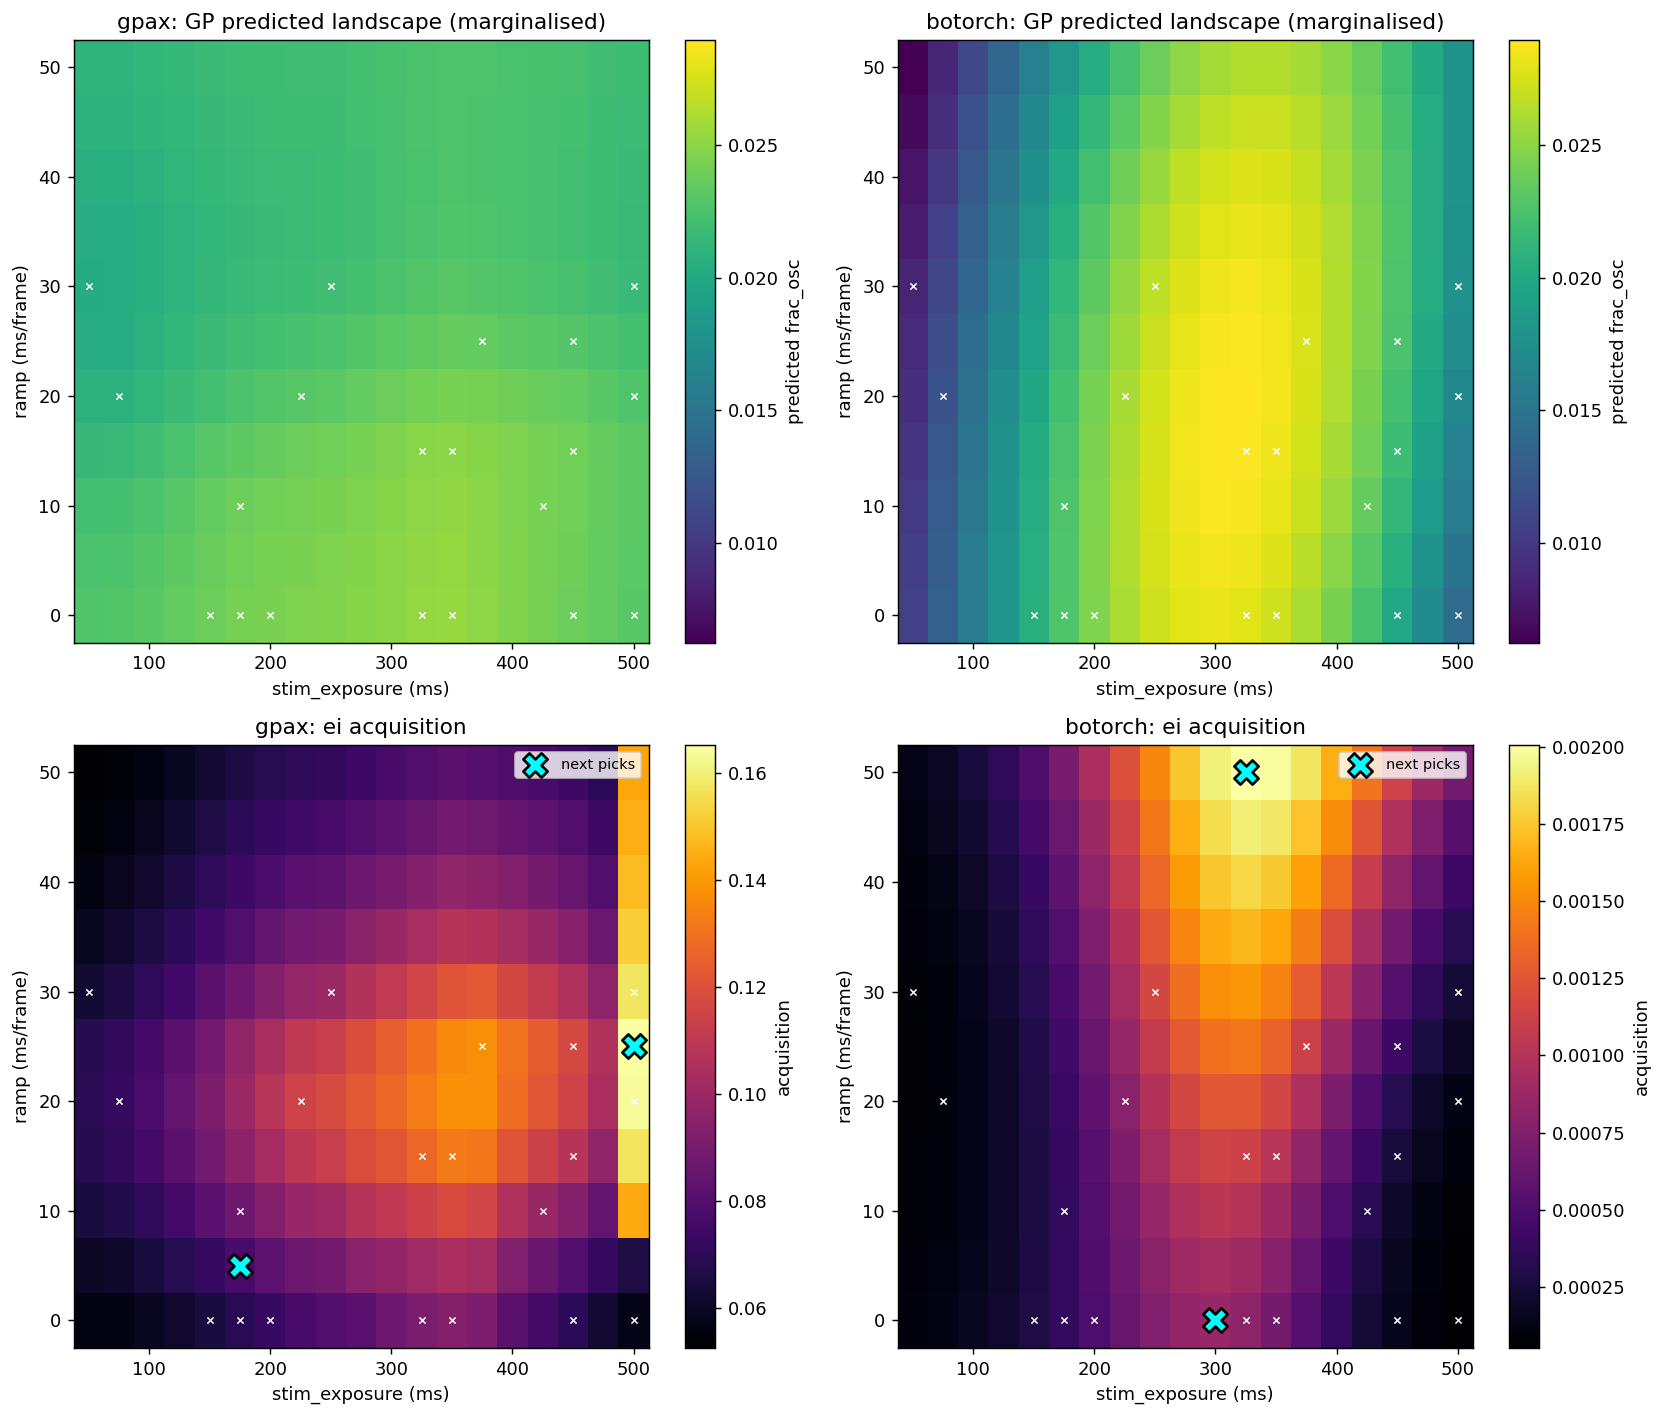

In [ ]:
# Control grid
x_tot = agent_g.x_total_linespace
ux1 = np.unique(x_tot[:, 0])
ux2 = np.unique(x_tot[:, 1])
n_ctrl = len(ux1) * len(ux2)
ctrl_grid = np.array([[x1, x2] for x1 in ux1 for x2 in ux2])
X_mesh, Y_mesh = np.meshgrid(ux1, ux2, indexing="ij")

# Joint covariate samples (same 50 for both backends for fair comparison)
cov_full = df_all[cov_cols].to_numpy(dtype=float)
rng = np.random.default_rng(0)
N_COV_PLOT = 50
cov_sub = cov_full[rng.integers(0, cov_full.shape[0], size=N_COV_PLOT)]
x_full = np.hstack(
    [np.repeat(ctrl_grid, N_COV_PLOT, axis=0), np.tile(cov_sub, (n_ctrl, 1))]
)

# gpax landscape
mean_s, _ = ctx_g["gp_model"].predict(
    ctx_g["rng_key_predict"], ctx_g["x_scaler"].transform(x_full), noiseless=True
)
y_g = ctx_g["y_scaler"].inverse_transform(np.asarray(mean_s).reshape(-1, 1)).flatten()
y_g = y_g.reshape(n_ctrl, N_COV_PLOT).mean(axis=1).reshape(len(ux1), len(ux2))

# BoTorch landscape
X_t = torch.tensor(agent_b._apply_log_transforms(x_full), dtype=torch.double)
with torch.no_grad():
    y_b = agent_b._last_plot_context["gp_model"].posterior(X_t).mean.squeeze(-1).numpy()
if bo_objective.log_scale:
    y_b = np.exp(y_b)
y_b = y_b.reshape(n_ctrl, N_COV_PLOT).mean(axis=1).reshape(len(ux1), len(ux2))


# Acquisition from agent (pad to full grid)
def _acq_grid(ctx):
    acq = np.asarray(ctx["acq_values_total"])
    if len(acq) == n_ctrl:
        return acq.reshape(len(ux1), len(ux2))
    pad = np.zeros(n_ctrl)
    for j, pt in enumerate(ctx["x_unmeasured_at_computation"]):
        diffs = np.abs(x_tot - pt).sum(axis=1)
        pad[int(np.argmin(diffs))] = float(acq[j]) if j < len(acq) else 0.0
    return pad.reshape(len(ux1), len(ux2))


acq_g = _acq_grid(ctx_g)
acq_b = _acq_grid(agent_b._last_plot_context)

# Shared color scales so the comparison is fair
lvmin = min(y_g.min(), y_b.min())
lvmax = max(y_g.max(), y_b.max())

fig, axes = plt.subplots(2, 2, figsize=(13, 11), dpi=130)

for col, (name, y_2d, picks) in enumerate(
    [
        ("gpax", y_g, picks_g),
        ("botorch", y_b, picks_b),
    ]
):
    ax = axes[0, col]
    im = ax.pcolormesh(
        X_mesh, Y_mesh, y_2d, cmap="viridis", shading="auto", vmin=lvmin, vmax=lvmax
    )
    fig.colorbar(im, ax=ax, label="predicted frac_osc")
    ax.scatter(
        df_all.stim_exposure,
        df_all.ramp,
        c="white",
        s=10,
        alpha=0.5,
        marker="x",
        linewidths=0.5,
    )
    ax.set_title(f"{name}: GP predicted landscape (marginalised)")
    ax.set_xlabel("stim_exposure (ms)")
    ax.set_ylabel("ramp (ms/frame)")

for col, (name, acq_2d, picks) in enumerate(
    [
        ("gpax", acq_g, picks_g),
        ("botorch", acq_b, picks_b),
    ]
):
    ax = axes[1, col]
    im = ax.pcolormesh(X_mesh, Y_mesh, acq_2d, cmap="inferno", shading="auto")
    fig.colorbar(im, ax=ax, label="acquisition")
    ax.scatter(
        df_all.stim_exposure,
        df_all.ramp,
        c="white",
        s=10,
        alpha=0.5,
        marker="x",
        linewidths=0.5,
    )
    picks_arr = np.array([[p["stim_exposure"], p["ramp"]] for p in picks])
    ax.scatter(
        picks_arr[:, 0],
        picks_arr[:, 1],
        c="cyan",
        s=180,
        marker="X",
        edgecolors="k",
        linewidths=1.5,
        zorder=10,
        label="next picks",
    )
    ax.legend(loc="upper right", fontsize=8)
    ax.set_title(
        f"{name}: {ctx_g['acquisition_used'] if name=='gpax' else agent_b._last_plot_context['acquisition_used']} acquisition"
    )
    ax.set_xlabel("stim_exposure (ms)")
    ax.set_ylabel("ramp (ms/frame)")

plt.tight_layout()
plt.show()

## Metric 4: kernel hyperparameters

Lengthscales tell you how 'wiggly' the GP thinks the landscape is per input dimension. Very short → overfitting noise; very long → underfitting.

In [ ]:
print("=== gpax kernel (posterior mean over MCMC) ===")
try:
    samples = ctx_g["gp_model"].mcmc.get_samples()
    for k in ("k_length", "k_scale", "noise"):
        if k in samples:
            v = np.asarray(samples[k])
            if v.ndim == 1:
                print(f"  {k}: {v.mean():.3f} ± {v.std():.3f}")
            else:
                print(
                    f"  {k}: {np.array2string(v.mean(axis=0), precision=3)} "
                    f"± {np.array2string(v.std(axis=0), precision=3)}"
                )
except Exception as e:
    print(f"  (unable to extract: {e})")

print("\n=== BoTorch kernel (MLE point estimate) ===")
m = agent_b._last_plot_context["gp_model"]
try:
    ls = m.covar_module.base_kernel.lengthscale.detach().cpu().numpy().flatten()
    print(f"  lengthscales: {np.array2string(ls, precision=3)}")
except Exception:
    pass
try:
    os_ = m.covar_module.outputscale.detach().cpu().numpy()
    print(f"  outputscale: {float(os_):.3f}")
except Exception:
    pass
try:
    noise = m.likelihood.noise.detach().cpu().numpy()
    print(f"  noise: {float(noise):.4f}")
except Exception:
    pass

print(
    "\nInput dimension order:",
    [p.name for p in bo_params] + [c.name for c in bo_covariates],
)

=== gpax kernel (posterior mean over MCMC) ===
  k_length: [2.326 1.966 1.127 0.773 1.8  ] ± [2.505 2.56  1.706 1.13  2.034]
  k_scale: 0.373 ± 0.219
  noise: 0.710 ± 0.218

=== BoTorch kernel (MLE point estimate) ===
  noise: 0.8576

Input dimension order: ['stim_exposure', 'ramp', 'n_cells', 'optortk_expression', 'baseline_cnr']


C:\Users\Jungfrau\AppData\Local\Temp\ipykernel_75148\1180460294.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"  noise: {float(noise):.4f}")


## Takeaway cheatsheet

**Red flags to watch for:**
- `acq used = ucb` when you asked for `ei` → silent fallback (should not happen after the `best_f` fix)
- `EI flat = True` → acquisition has no discriminative power
- `acq range < 1e-5` → BO is effectively picking at random
- Calibration scatter clumped at mean → GP is ignoring the data (over-regularised)
- Lengthscales < 0.3 on a z-scored input → GP is fitting noise

**Green flags:**
- `acq used = ei` on both backends
- Calibration: Pearson r > 0.5 on sparse objectives, predictions tracking y=x broadly
- Picks include BOTH an exploit point (near observed best) AND an explore point (unmeasured region)
- Lengthscales in [0.5, 5.0] on z-scored inputs
- BoTorch fit < 3 s, gpax fit < 30 s

**When BoTorch tends to win:**
- Zero-inflated / rare-event objectives (MLE regularises, MCMC chases modes)
- Many observations (100+) where MCMC becomes slow
- When you want faster BO loops

**When gpax tends to win:**
- Small data (< 30 obs) where MCMC's posterior averaging is a real advantage
- When kernel hyperparameters are poorly identified and point-estimates would be misleading
- When you want calibrated uncertainty for downstream decisions (not just for EI)